Overview

In this assignment, you will work on the "blogs_categories.csv" dataset, which contains blog posts categorized into various themes. Your task will be to build a text classification model using the Naive Bayes algorithm to categorize the blog posts accurately. Furthermore, you will perform sentiment analysis to understand the general sentiment (positive, negative, neutral) expressed in these posts. This assignment will enhance your understanding of text classification, sentiment analysis, and the practical application of the Naive Bayes algorithm in Natural Language Processing (NLP).

Dataset

The provided dataset, "blogs_categories.csv", consists of blog posts along with their associated categories. Each row represents a blog post with the following columns:

•	Text: The content of the blog post. Column name: Data

•	Category: The category to which the blog post belongs. Column name: Labels


Tasks
1. Data Exploration and Preprocessing

•	Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.

•	Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.

•	Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.


In [ ]:
#load the dataset
import pandas as pd
df=pd.read_csv('/content/blogs.csv')
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [ ]:
df['len']=df['Data'].apply(len)

array([[<Axes: title={'center': 'alt.atheism'}>,
        <Axes: title={'center': 'comp.graphics'}>,
        <Axes: title={'center': 'comp.os.ms-windows.misc'}>,
        <Axes: title={'center': 'comp.sys.ibm.pc.hardware'}>],
       [<Axes: title={'center': 'comp.sys.mac.hardware'}>,
        <Axes: title={'center': 'comp.windows.x'}>,
        <Axes: title={'center': 'misc.forsale'}>,
        <Axes: title={'center': 'rec.autos'}>],
       [<Axes: title={'center': 'rec.motorcycles'}>,
        <Axes: title={'center': 'rec.sport.baseball'}>,
        <Axes: title={'center': 'rec.sport.hockey'}>,
        <Axes: title={'center': 'sci.crypt'}>],
       [<Axes: title={'center': 'sci.electronics'}>,
        <Axes: title={'center': 'sci.med'}>,
        <Axes: title={'center': 'sci.space'}>,
        <Axes: title={'center': 'soc.religion.christian'}>],
       [<Axes: title={'center': 'talk.politics.guns'}>,
        <Axes: title={'center': 'talk.politics.mideast'}>,
        <Axes: title={'center': 'ta

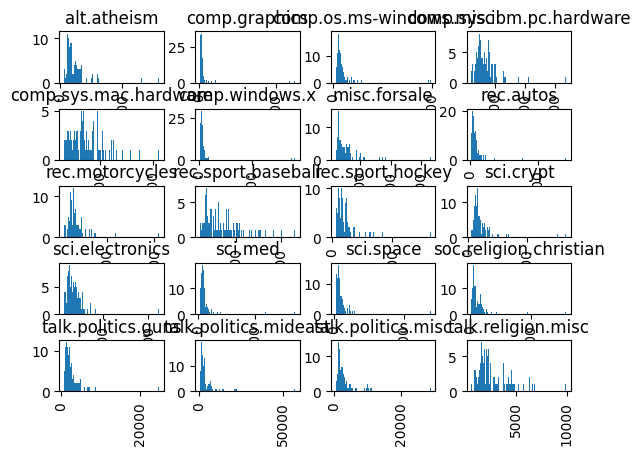

In [ ]:
df.hist('len',by='Labels',bins=100)

In [ ]:
import nltk
nltk.download('all')
import spacy
nlp= spacy.load('en_core_web_sm')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize,word_tokenize
from nltk.corpus import stopwords

In [ ]:
import re

In [ ]:
## Data Cleaning
def cleanwords(data):
    data= ' '.join(re.findall('\w+',data))
    doc= nlp(data)
    clean_text= [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_digit
                 and not token.is_bracket and not token.is_currency]
    return clean_text

In [ ]:
#feature extraction
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer

In [ ]:
count= CountVectorizer(analyzer=cleanwords)

In [ ]:
x= count.fit_transform(df['Data'])

In [ ]:
x.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
x.shape

(2000, 46683)

In [ ]:
tfidf= TfidfTransformer()

In [ ]:
y=tfidf.fit_transform(x)

2. Naive Bayes Model for Text Classification

•	Split the data into training and test sets.

•	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.

•	Train the model on the training set and make predictions on the test set.


In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
multi= MultinomialNB()

In [ ]:
multi.fit(y,df['Labels'])

MultinomialNB()

In [ ]:
y_pred= multi.predict(y)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(df['Data'],df['Labels'],train_size=0.75, random_state=100)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1500,)
(500,)
(1500,)
(500,)


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
pipeline= Pipeline([('count',CountVectorizer(analyzer=cleanwords)),('tfidf',TfidfTransformer()),
                   ('multi',MultinomialNB())])

In [ ]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('count',
                 CountVectorizer(analyzer=<function cleanwords at 0x79485ee571a0>)),
                ('tfidf', TfidfTransformer()), ('multi', MultinomialNB())])

In [ ]:
y_pred=pipeline.predict(x_test)

3. Sentiment Analysis

•	Choose a suitable library or method for performing sentiment analysis on the blog post texts.

•	Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. Consider only the Data column and get the sentiment for each blog.

•	Examine the distribution of sentiments across different categories and summarize your findings.


In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
def sentiment(text):
    sent= TextBlob(text)
    return sent.sentiment.polarity

In [ ]:
def blobsentiment(text):
    sent= TextBlob(text)
    sentiment=sent.sentiment.polarity
    if sentiment>0:
      return 1
    elif sentiment<0:
      return -1
    else:
      return 0

In [ ]:
df['Text_blob']= df['Data'].apply(blobsentiment)

In [ ]:
df

,Data,Labels,len,Text_blob
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,5972,1
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,1336,-1
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,3116,1
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,15910,1
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,3264,1
...,...,...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc,5263,1
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,1771,1
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc,2192,1
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,3197,1


<Axes: xlabel='Text_blob', ylabel='count'>

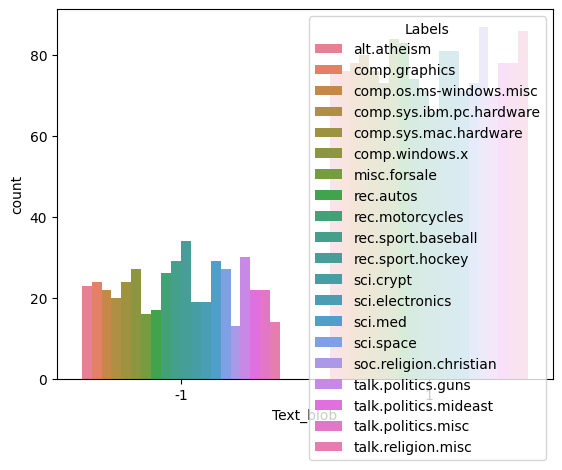

In [ ]:
import seaborn as sns
sns.countplot(data=df,x='Text_blob',hue='Labels')

4. Evaluation

•	Evaluate the performance of your Naive Bayes classifier using metrics such as accuracy, precision, recall, and F1-score.

•	Discuss the performance of the model and any challenges encountered during the classification process.

•	Reflect on the sentiment analysis results and their implications regarding the content of the blog posts.


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.822

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred))

                          precision    recall  f1-score   support

             alt.atheism       0.62      0.95      0.75        19
           comp.graphics       0.84      0.57      0.68        28
 comp.os.ms-windows.misc       0.93      0.97      0.95        29
comp.sys.ibm.pc.hardware       0.75      0.81      0.78        26
   comp.sys.mac.hardware       0.56      0.82      0.67        22
          comp.windows.x       0.80      0.70      0.74        23
            misc.forsale       0.86      0.75      0.80        24
               rec.autos       0.87      0.71      0.78        28
         rec.motorcycles       0.85      0.85      0.85        20
      rec.sport.baseball       0.85      0.92      0.88        24
        rec.sport.hockey       0.93      0.87      0.90        31
               sci.crypt       0.83      1.00      0.91        25
         sci.electronics       0.88      0.64      0.74        22
                 sci.med       0.95      0.76      0.84        25
         

In [50]:
'''
In this model,neutral sentiment is not captured.
and the sentiment is skewed on the positive side.
'''

'\nIn this model,neutral sentiment is not captured.\nand the sentiment is skewed on the positive side.\n'